# Proyecto Final - Sistema de detección de enfermedades en hojas de café

**Curso:** *Vision Computacional con Deep Learning*

**Implementado por:** *Valentina Bueno Collazos, David Alejandro Cajiao Lazt, Natalia Moreno Montoya*

Este proyecto desarrolla un sistema de **detección automática de enfermedades en hojas de café** mediante visión computacional y deep learning. Se empleó el modelo YOLOv8n con fine-tuning sobre el dataset *Coffee Leaf*, con imágenes anotadas bajo 4 condiciones: hoja sana (healthy), minador (miner), phoma y roya (rust).

El pipeline completo abarca la descarga y el análisis exploratorio de los datos, el fine-tuning con data augmentation, la evaluación cuantitativa con métricas estándar de detección y el análisis de errores. El modelo entrenado alcanzo **mAP@0.5** de **0.9587**, con precisión de 0.9383 y recall de 0.9614, lo que demuestra alta capacidad de generalización.

La solución integra la salida del modelo dentro de un pipeline orienntado a apoyar la toma de decisiones fitosanitarias en cultivos de café, generando reportes que pueden guiar intervenciones agronómicas tempranas.

## Introducción

### Definición y Justificación del problema

Colombia es uno de los principales productores de café a nivel mundial; sin embargo, las enfermedades foliares como la roya, el minador de hoja y la phoma representan una amenaza constante para la productividad de los cultivos. La detección temprana de estas enfermedades es crítica, porque una intervención oportuna puede reducir significativamente las pérdidas económicas y el uso de agroquímicos.

El monitoreo tradicional depende de la inspección visual manual por parte de expertos agrónomos, lo que resulta costoso, lento y no escalable para grandes extensiones de cultivo. La visión computacional aporta valor real en este contexto, permite analizar imágenes capturadas con smartphones o con otras herramientas de forma automática, objetiva y en tiempo real, democratizando el acceso al diagnóstico fitosanitario.

### Dataset

Se utiliza el dataset *Coffee Leaf*, con imágenes de hojas de café anotadas con bounding boxes. El dataset incluye 4 clases con imágenes capturadas en diferentes condiciones de iluminación y la anotación fue realizada por expertos. El dataset cuenta con 3.993 imágenes de entrenamiento y 167 de validación.

### Modelo seleccionado YOLOv8

Es un detector one-stage de última generación que realiza la localización y clasificación en una única pasada por la red, lo que lo hace apropiado para despliegue en campo o integración con aplicaciones móviles. Se eligió la variante yolov8n por su bajo costo computacional, suficiente para el tamaño del dataset disponible. El fine-tuning aprovecha los pesos preentrenados en COCO para inicializar el backbone, reduciendo el riesgo de overfitting con datasets pequeños.

## Sección 0 — Instalación, Librerías y verificación del entorno

In [ ]:
!pip install ultralytics roboflow --quiet

import torch
from ultralytics import YOLO
from pathlib import Path
import yaml, random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import collections
from PIL import Image
import random, numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA disponible : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"Memoria GPU     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("ADVERTENCIA: No se detectó GPU.")
    print("Ve a Runtime > Change runtime type > T4 GPU antes de continuar.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 66.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch version : 2.11.0+cu128
CUDA disponible : True
GPU             : Tesla T4
Memoria GPU     : 15.6 GB


## Sección 1 — Descarga del dataset

Se utiliza el dataset **Coffee Leaf** (versión 6) del workspace `tugas-akhir-adf4p` en Roboflow, que contiene imágenes de hojas de café anotadas con enfermedades como roya, minador y phoma.

In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key="yr9XcMwiZgFT52Jea6dK")
project = rf.workspace("tugas-akhir-adf4p").project("coffee-leaf")
version = project.version(6)
dataset = version.download("yolov8")

print(f"\nDataset descargado en: {dataset.location}")
print(f"data.yaml: {dataset.location}/data.yaml")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Coffee-Leaf-6 in yolov8:: 100%|██████████| 8664/8664 [00:01<00:00, 7286.70it/s]


Dataset descargado en: /content/Coffee-Leaf-6
data.yaml: /content/Coffee-Leaf-6/data.yaml


In [ ]:
# Ruta al data.yaml generado por Roboflow
YAML_PATH = f"{dataset.location}/data.yaml"

with open(YAML_PATH) as f:
    cfg = yaml.safe_load(f)

print("Contenido de data.yaml:")
print("-" * 40)
for k, v in cfg.items():
    print(f"  {k}: {v}")

NAMES    = cfg["names"]
BASE_DIR = Path(dataset.location)

print(f"\nClases encontradas ({cfg['nc']} total): {NAMES}")

# Contar imágenes disponibles
train_imgs = sorted((BASE_DIR / "train" / "images").glob("*.*"))
val_imgs   = sorted((BASE_DIR / "valid" / "images").glob("*.*"))

print(f"Imágenes train : {len(train_imgs)}")
print(f"Imágenes val   : {len(val_imgs)}")

Contenido de data.yaml:
----------------------------------------
  names: ['healthy', 'miner', 'phoma', 'rust']
  nc: 4
  roboflow: {'license': 'CC BY 4.0', 'project': 'coffee-leaf', 'url': 'https://universe.roboflow.com/tugas-akhir-adf4p/coffee-leaf/dataset/6', 'version': 6, 'workspace': 'tugas-akhir-adf4p'}
  test: ../test/images
  train: ../train/images
  val: ../valid/images

Clases encontradas (4 total): ['healthy', 'miner', 'phoma', 'rust']
Imágenes train : 3993
Imágenes val   : 167


## Sección 2 — Exploración del dataset

Antes de iniciar el entrenamiento, se debe analizar el conjunto de datos verificando aspectos como la distribución de clases, la cantidad de objetos en cada imagen y algunos ejemplos visuales.

#### Distribución de objetos por clase

La gráfica de la izquierda muestra un desbalance de clases significativo: rust concentra la mayoría de instancias, seguido de miner, phoma y healthy. Este desbalance es relevante porque el modelo tiende a aprender mejor las clases mayoritarias; por eso se activo el data augmentation por mosaico (`mosaic=1.0`) y mixup (`mixup=0.1`), que exponen al modelo a combinaciones artificiales de imágenes y fuerzan la presencia de clases minoritarias en cada batch de entrenamiento.

La gráfica de la derecha muestra que la mayoría de las imágenes contienen entre 1 y 4 objetos, con una distribución fuertemente sesgada hacia la derecha. Sin embargo, existen imágenes con hasta 40 objetos anotados, lo que corresponde principalmente a hojas con infección severa de rust, cuyas lesiones son pequeñas y numerosas. Precisamente por esto se fijó `IMG_SIZE=640`, una resolución menor comprimiría estas lesiones hasta hacerlas indistinguibles entre sí, perdiendo información que el modelo necesita para localizarlas correctamente.

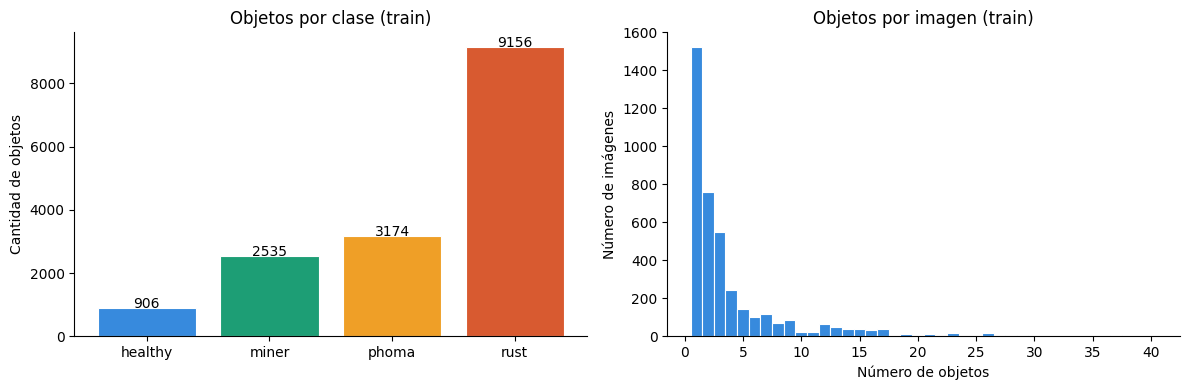

Total objetos en train  : 15771
Objetos por imagen      : min=1, max=40, promedio=3.9


In [ ]:
conteo         = collections.Counter()
obj_por_imagen = []

for lbl_file in sorted((BASE_DIR / "train" / "labels").glob("*.txt")):
    lineas = [l for l in lbl_file.read_text().strip().splitlines() if l]
    obj_por_imagen.append(len(lineas))
    for l in lineas:
        conteo[int(l.split()[0])] += 1

COLORES = ["#378ADD", "#1D9E75", "#EF9F27", "#D85A30", "#7F77DD"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

nombres_ord    = [NAMES[k] for k in sorted(conteo.keys())]
valores_ord    = [conteo[k] for k in sorted(conteo.keys())]
colores_barras = COLORES[:len(nombres_ord)]

axes[0].bar(nombres_ord, valores_ord, color=colores_barras,
            edgecolor="white", linewidth=0.8)
axes[0].set_title("Objetos por clase (train)", fontsize=12)
axes[0].set_ylabel("Cantidad de objetos")
axes[0].spines[["top", "right"]].set_visible(False)
for i, v in enumerate(valores_ord):
    axes[0].text(i, v + 0.3, str(v), ha="center", fontsize=10)

axes[1].hist(obj_por_imagen, bins=range(1, max(obj_por_imagen) + 2),
             color="#378ADD", edgecolor="white", linewidth=0.8, align="left")
axes[1].set_title("Objetos por imagen (train)", fontsize=12)
axes[1].set_xlabel("Número de objetos")
axes[1].set_ylabel("Número de imágenes")
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Total objetos en train  : {sum(valores_ord)}")
print(f"Objetos por imagen      : min={min(obj_por_imagen)}, "
      f"max={max(obj_por_imagen)}, "
      f"promedio={sum(obj_por_imagen)/len(obj_por_imagen):.1f}")

#### Visualizar imágenes del conjunto de datos con sus respectivas bounding boxes

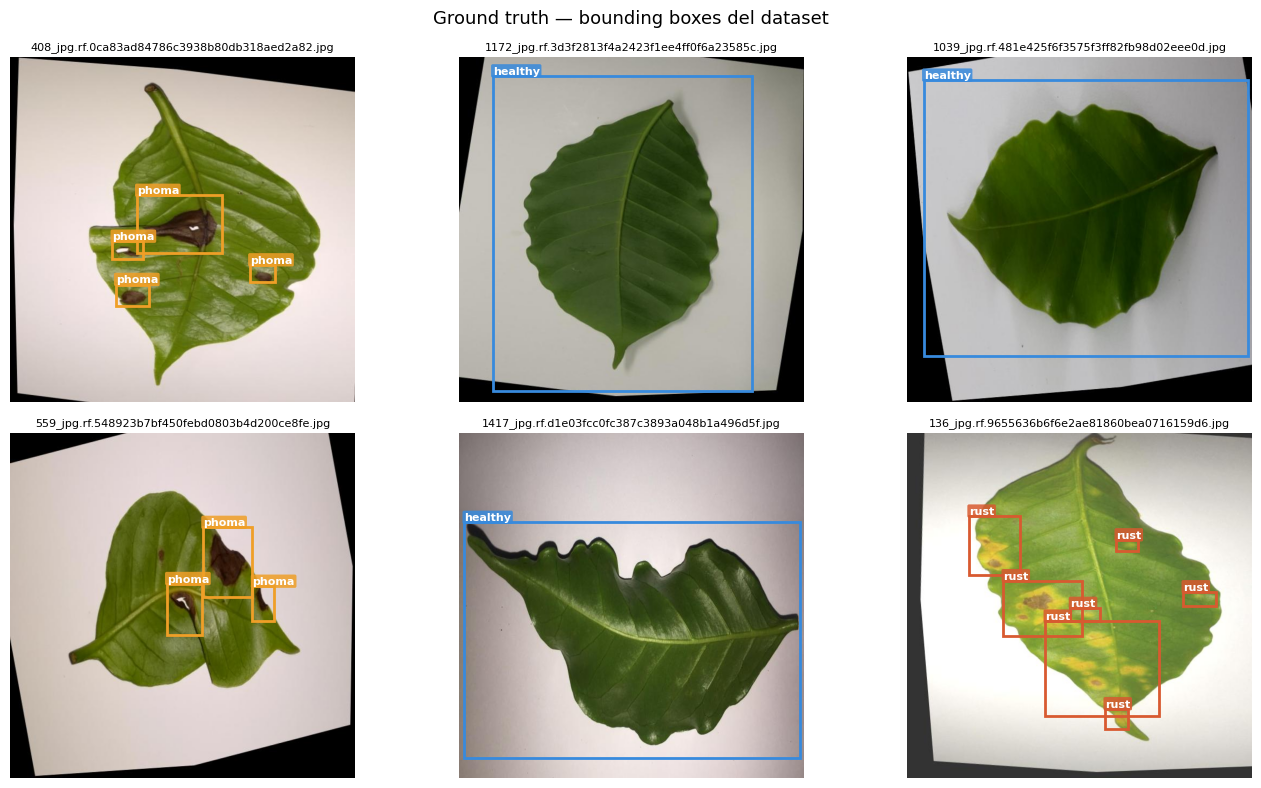

In [ ]:
# Visualizar imágenes con bounding boxes del ground truth
muestra = random.sample(train_imgs, min(6, len(train_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Ground truth — bounding boxes del dataset", fontsize=13)

for ax, img_path in zip(axes.flat, muestra):
    img = Image.open(img_path).convert("RGB")
    w, h = img.size
    ax.imshow(img)

    lbl_path = BASE_DIR / "train" / "labels" / (img_path.stem + ".txt")
    if lbl_path.exists():
        for linea in lbl_path.read_text().strip().splitlines():
            if not linea:
                continue
            cid, xc, yc, bw, bh = map(float, linea.split())
            cid   = int(cid)
            x1    = (xc - bw / 2) * w
            y1    = (yc - bh / 2) * h
            color = COLORES[cid % len(COLORES)]

            rect = patches.Rectangle(
                (x1, y1), bw * w, bh * h,
                linewidth=2, edgecolor=color, facecolor="none"
            )
            ax.add_patch(rect)
            ax.text(
                x1, y1 - 4, NAMES[cid],
                color="white", fontsize=8, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.15", fc=color,
                          alpha=0.85, ec="none")
            )
    ax.axis("off")
    ax.set_title(img_path.name, fontsize=8)

plt.tight_layout()
plt.show()

## Sección 3 — Fine-tuning de YOLOv8

#### Configuración del entrenamiento

In [ ]:
MODELO_BASE = "yolov8n.pt" # modelo base
EPOCHS      = 50
IMG_SIZE    = 640
BATCH_SIZE  = 16
LR0         = 0.01
PATIENCE    = 15
EXPERIMENTO = "coffee_leaf_v6"

print("Configuración de entrenamiento:")
print(f"  Modelo base   : {MODELO_BASE}")
print(f"  Dataset yaml  : {YAML_PATH}")
print(f"  Clases        : {NAMES}")
print(f"  Épocas        : {EPOCHS}")
print(f"  Tamaño imagen : {IMG_SIZE}")
print(f"  Batch size    : {BATCH_SIZE}")
print(f"  Learning rate : {LR0}")
print(f"  Early stop    : {PATIENCE} épocas sin mejora")
print(f"  Experimento   : runs/detect/{EXPERIMENTO}")

Configuración de entrenamiento:
  Modelo base   : yolov8n.pt
  Dataset yaml  : /content/Coffee-Leaf-6/data.yaml
  Clases        : ['healthy', 'miner', 'phoma', 'rust']
  Épocas        : 50
  Tamaño imagen : 640
  Batch size    : 16
  Learning rate : 0.01
  Early stop    : 15 épocas sin mejora
  Experimento   : runs/detect/coffee_leaf_v6


#### Entrenamiento

In [ ]:
# Cargar el modelo base
model = YOLO(MODELO_BASE)

results_train = model.train(
    data      = YAML_PATH,
    epochs    = EPOCHS,
    imgsz     = IMG_SIZE,
    batch     = BATCH_SIZE,
    lr0       = LR0,
    patience  = PATIENCE,
    name      = EXPERIMENTO,
    # Data Augmentation
    mosaic    = 1.0,
    fliplr    = 0.5,
    flipud    = 0.0,
    degrees   = 10.0,
    mixup     = 0.1,
    verbose   = True,
)

MEJOR_MODELO = model.trainer.best
print("\nEntrenamiento completado")
print(f"Mejor modelo guardado en: {MEJOR_MODELO}")

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Coffee-Leaf-6/data.yaml, degrees=10.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=coffee_leaf_v6, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, 

## Sección 4— Evaluación del modelo

In [ ]:
# Cargar el mejor checkpoint del entrenamiento
model_eval = YOLO(MEJOR_MODELO)

# Evaluar sobre el conjunto de validación
metricas = model_eval.val(
    data    = YAML_PATH,
    imgsz   = IMG_SIZE,
    conf    = 0.30,
    iou     = 0.45,
    verbose = True,
)

# Mostrar resumen de métricas
print("\n" + "=" * 50)
print("MÉTRICAS GLOBALES (promedio sobre todas las clases)")
print("=" * 50)
print(f"  Precision   : {metricas.box.mp:.4f}")
print(f"  Recall      : {metricas.box.mr:.4f}")
print(f"  mAP@0.5     : {metricas.box.map50:.4f}")
print(f"  mAP@0.5:95  : {metricas.box.map:.4f}")

print("\nMÉTRICAS POR CLASE")
print("-" * 30)
print(f"  {'-'*15} {'-'*8}")
for i, (ap, p, r) in enumerate(zip(metricas.box.ap50,
                                    metricas.box.p,
                                    metricas.box.r)):
    print(f"  {NAMES[i]:<15} MAP@50={ap:.4f}  P={p:.4f}  R={r:.4f}")

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 960.3±289.8 MB/s, size: 27.5 KB)
val: Scanning /content/Coffee-Leaf-6/valid/labels.cache... 167 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 167/167 70.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 3.5it/s 3.2s
                   all        167        721      0.938      0.961      0.959       0.71
               healthy         46         46          1          1      0.995      0.919
                 miner         65        167      0.949      0.982      0.982      0.743
                 phoma         21         40      0.939          1      0.993      0.758
                  rust         42        468      0.865      0.864      0.865      0.419
Speed: 3.6ms preprocess, 4.7ms inference, 0.

El modelo alcanzo un mAP@0.5 de 0.9587, lo que indica una capacidad de detección sobresaliente. Las tres primeras clases superan el 0.98 de mAP@0.5, mientras que rust queda notablemente por debajo con 0.8649. Esta brecha no es aleatoria, rust concentra  el 59% de las instancias y es la clase con mayor número de objetos por imagen; esto genera dos problemas específicos:

- Las lesiones son pequeñas y se solapan, dificultando que el modelo asigne un bounding box correcto a cada una individualmente.
- Su apariencia varía según el estadio de la infección, pudiendo confundirse visualmente con clorosis natural de la hoja o perderse entre manchas agrupadas.

Por otro lado, se presenta una diferencia significativa de resultados entre el mAP@0.5 vs mAP@0.5:0.95. El salto de 0.9587 a 0.7097 al evaluar con estos umbrales de IoU  más estrictos indica que el modelo localiza bien los objetos pero los bounding boxes no son perfectamente ajustados, esto es esperable con YOLOv8n y con lesiones de forma irregular como las de rust. Para aplicaciones donde solo importa detectar la presencia de la enfermedad, mAP@0.5 es el indicador relevante; si se requiriera segmentación precisa del área afectada, habría que migrar a un modelo de segmentación.

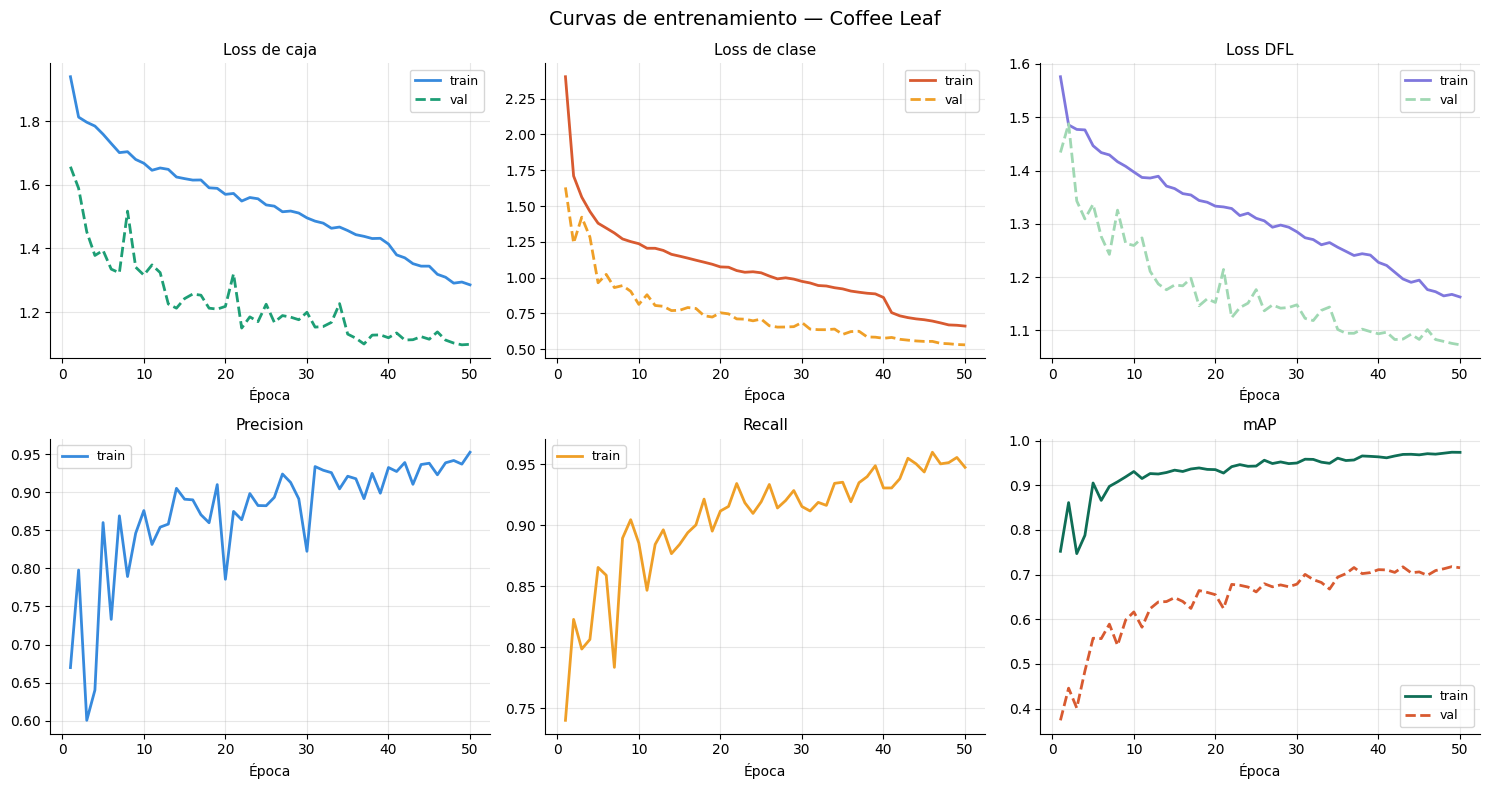

In [ ]:
import pandas as pd

run_dir     = Path(f"runs/detect/{EXPERIMENTO}")
results_csv = run_dir / "results.csv"

if not results_csv.exists():
    print(f"No se encontró results.csv en {run_dir}")
else:
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    # Agrupadas por tema: losses juntas, métricas juntas
    columnas_a_graficar = [
        # Fila 1 — Losses comparativas
        ("train/box_loss",       "val/box_loss",         "Loss de caja",   "#378ADD", "#1D9E75"),
        ("train/cls_loss",       "val/cls_loss",         "Loss de clase",  "#D85A30", "#EF9F27"),
        ("train/dfl_loss",       "val/dfl_loss",         "Loss DFL",       "#7F77DD", "#A0D8B3"),
        # Fila 2 — Métricas
        ("metrics/precision(B)", None,                   "Precision",      "#378ADD", None),
        ("metrics/recall(B)",    None,                   "Recall",         "#EF9F27", None),
        ("metrics/mAP50(B)",     "metrics/mAP50-95(B)",  "mAP",            "#0F6E56", "#D85A30"),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle("Curvas de entrenamiento — Coffee Leaf", fontsize=14)

    for ax, (col_train, col_val, titulo, color_train, color_val) in zip(axes.flat, columnas_a_graficar):
        plotted = False

        if col_train and col_train in df.columns:
            ax.plot(df["epoch"], df[col_train],
                    color=color_train, linewidth=2,
                    label="train")
            plotted = True

        if col_val and col_val in df.columns:
            ax.plot(df["epoch"], df[col_val],
                    color=color_val, linewidth=2,
                    linestyle="--", label="val")
            plotted = True

        if plotted:
            ax.set_title(titulo, fontsize=11)
            ax.set_xlabel("Época")
            ax.legend(fontsize=9)
            ax.grid(True, alpha=0.3)
            ax.spines[["top", "right"]].set_visible(False)
        else:
            ax.text(0.5, 0.5, f"Columna no encontrada:\n{col_train}",
                    ha="center", va="center",
                    transform=ax.transAxes, color="gray", fontsize=9)
            ax.axis("off")

    plt.tight_layout()
    plt.show()

- Las tres losses de entrenamiento descienden de forma sostenida durante las 50 épocas sin estancamiento, lo que indica que el modelo seguía aprendiendo hasta el final. Las curvas de validación siguen una tendencia descendente paralela a las de entrenamiento sin divergir, lo que indica que el modelo está generalizando correctamente y no memorizando el conjunto de entrenamiento. Las oscilaciones que hay en validación durante las primeras  25 épocas son normales por el tamaño reducido de los datos de validación, con pocos ejemplos el gradiente de validación es más ruidoso.

- La precisión y el recall ascienden progresivamente y se estabilizan por la época 35, llegando a valores finales de ~0.95. Las oscilaciones que hay en las primeras épocas reflejan que el modelo aún esta ajustando el umbral de confianza óptimo para cada clase.

- La gráfica del mAP muestra la brecha más relevante del modelo, mAP@0.5 (línea de color verde) se estabiliza cerca de 0.96, mientras que mAP@0.5:0.95 (linea de color rojo) converge alrededor de 0.71. Esta diferencia no indica un problema de entrenamiento sino una limitación estructural, el modelo detecta correctamente la presencia y ubicación general de las enfermedades, pero los bounding boxes no se ajustan con la precisión milimétrica que exigen los umbrales más estrictos. Esto es esperado con lesiones de forma irregular como las de rust y con la variante del modelo utilizada.

## Sección 5 — Inferencia sobre imágenes de validación

Se ejecuta el modelo sobre un subconjunto de imágenes de validación y se visualizan las predicciones junto a la confianza de cada detección.

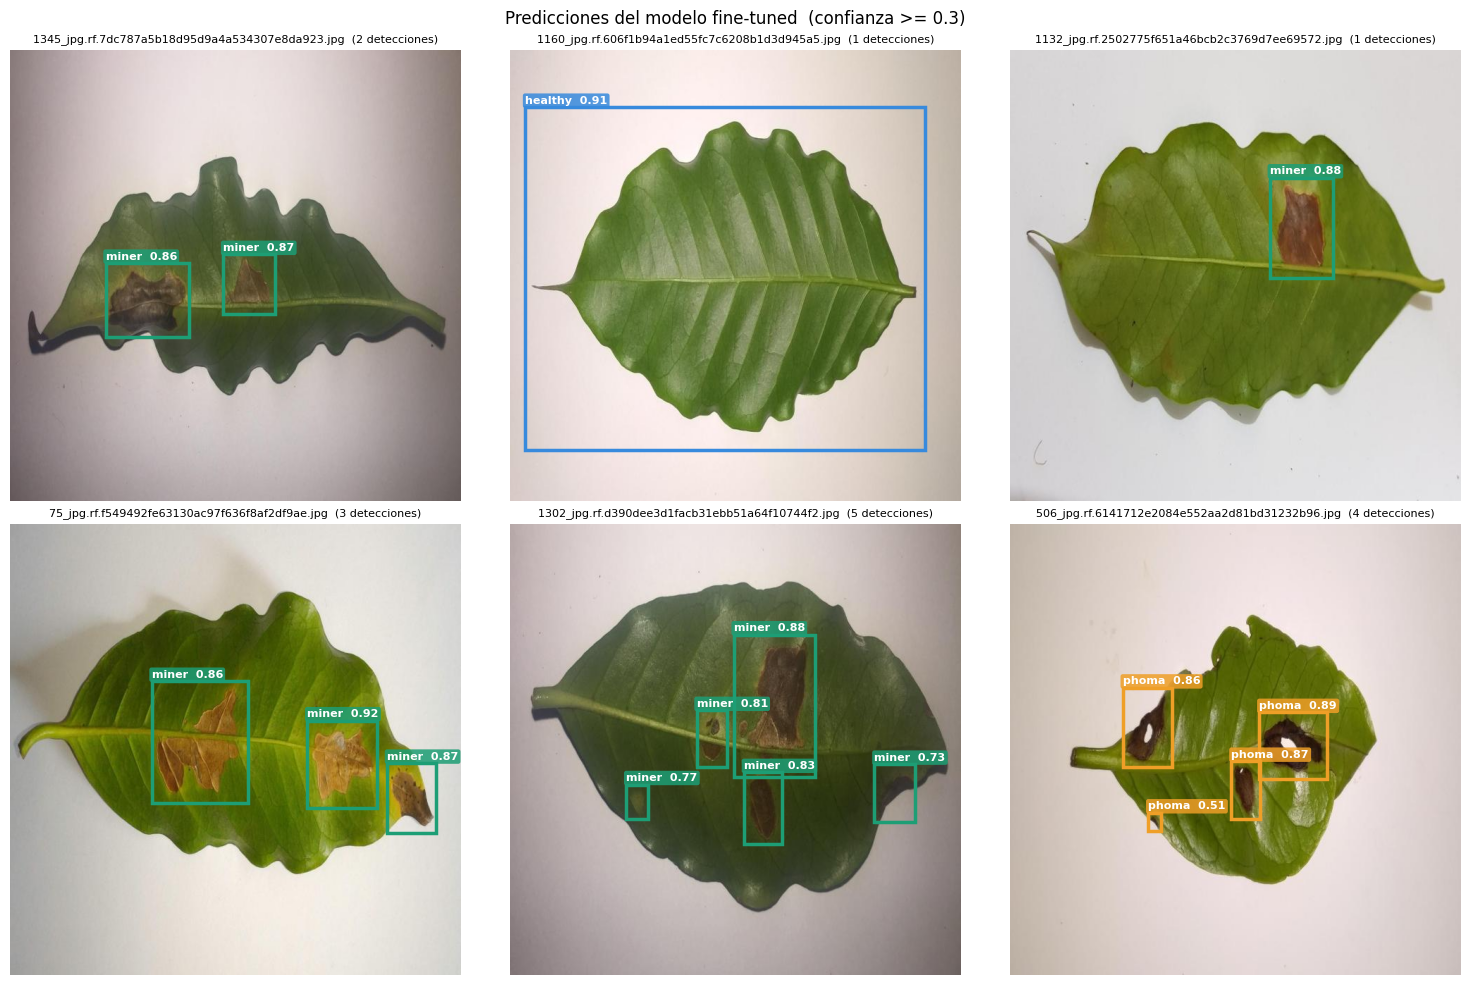

In [ ]:
UMBRAL_CONFIANZA = 0.30
UMBRAL_NMS       = 0.45
N_MOSTRAR        = 6

muestra = random.sample(val_imgs, min(N_MOSTRAR, len(val_imgs)))

cols = 3
rows = (len(muestra) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes_flat = axes.flat if rows > 1 else list(axes)

for ax, img_path in zip(axes_flat, muestra):
    img = Image.open(img_path).convert("RGB")
    w, h = img.size

    predicciones = model_eval.predict(
        source  = str(img_path),
        conf    = UMBRAL_CONFIANZA,
        iou     = UMBRAL_NMS,
        verbose = False,
    )[0]

    ax.imshow(img)

    for box in predicciones.boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        cid    = int(box.cls[0])
        conf   = float(box.conf[0])
        color  = COLORES[cid % len(COLORES)]
        nombre = NAMES[cid] if cid < len(NAMES) else f"cls_{cid}"

        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2.5, edgecolor=color, facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(
            x1, y1 - 5,
            f"{nombre}  {conf:.2f}",
            color="white", fontsize=8, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.2", fc=color, alpha=0.85, ec="none")
        )

    n_det = len(predicciones.boxes)
    ax.set_title(f"{img_path.name}  ({n_det} detecciones)", fontsize=8)
    ax.axis("off")

for ax in list(axes_flat)[len(muestra):]:
    ax.axis("off")

fig.suptitle(
    f"Predicciones del modelo fine-tuned  (confianza >= {UMBRAL_CONFIANZA})",
    fontsize=12
)
plt.tight_layout()
plt.show()

## Sección 6 — Análisis de errores

In [ ]:
def calcular_iou(caja_pred, caja_gt):
    """
    Calcula el Intersection over Union (IoU) entre dos cajas.
    Las cajas deben estar en formato [x1, y1, x2, y2].
    """
    xi1 = max(caja_pred[0], caja_gt[0])
    yi1 = max(caja_pred[1], caja_gt[1])
    xi2 = min(caja_pred[2], caja_gt[2])
    yi2 = min(caja_pred[3], caja_gt[3])

    interseccion = max(0, xi2 - xi1) * max(0, yi2 - yi1)
    area_pred    = (caja_pred[2] - caja_pred[0]) * (caja_pred[3] - caja_pred[1])
    area_gt      = (caja_gt[2]   - caja_gt[0])   * (caja_gt[3]   - caja_gt[1])
    union        = area_pred + area_gt - interseccion

    return interseccion / union if union > 0 else 0.0


# Calcular FP y FN por imagen sobre el conjunto de validación
errores_por_imagen = []

for img_path in val_imgs:
    lbl_path = BASE_DIR / "valid" / "labels" / (img_path.stem + ".txt")
    img      = Image.open(img_path)
    w, h     = img.size

    gt_boxes = []
    if lbl_path.exists():
        for linea in lbl_path.read_text().strip().splitlines():
            if not linea:
                continue
            cid, xc, yc, bw, bh = map(float, linea.split())
            x1 = (xc - bw / 2) * w
            y1 = (yc - bh / 2) * h
            x2 = (xc + bw / 2) * w
            y2 = (yc + bh / 2) * h
            gt_boxes.append((int(cid), [x1, y1, x2, y2]))

    preds_raw = model_eval.predict(
        source=str(img_path),
        conf=UMBRAL_CONFIANZA,
        iou=UMBRAL_NMS,
        verbose=False
    )[0]

    pred_boxes = [
        (int(b.cls[0]), b.xyxy[0].tolist(), float(b.conf[0]))
        for b in preds_raw.boxes
    ]

    gt_matched = set()
    fp = 0

    for pcid, pbox, _ in pred_boxes:
        encontrado = False
        for gi, (gcid, gbox) in enumerate(gt_boxes):
            if gi in gt_matched:
                continue
            if pcid == gcid and calcular_iou(pbox, gbox) >= 0.5:
                gt_matched.add(gi)
                encontrado = True
                break
        if not encontrado:
            fp += 1

    fn    = len(gt_boxes) - len(gt_matched)
    total = fp + fn
    errores_por_imagen.append((total, fp, fn, img_path))

errores_por_imagen.sort(reverse=True)

total_fp = sum(e[1] for e in errores_por_imagen)
total_fn = sum(e[2] for e in errores_por_imagen)
print(f"Análisis sobre {len(val_imgs)} imágenes de validación")
print(f"  Total falsos positivos : {total_fp}")
print(f"  Total falsos negativos : {total_fn}")
print(f"  Imágenes sin errores   : {sum(1 for e in errores_por_imagen if e[0] == 0)}")

Análisis sobre 167 imágenes de validación
  Total falsos positivos : 102
  Total falsos negativos : 62
  Imágenes sin errores   : 123


De las 167 imágenes evaluadas, 123 (74%) no representaron ningún error, lo que es consistente con el mAP@0.5 obtenido. Los errores se concentran en las 44 imágenes restantes, con un patrón relevante:

- El modelo tiende más a detectar de más que a omitir, lo que es ideal para una lectura agronómica concreta. En un sistema de alerta fitosanitaria, un falso positivo genera una inspección innecesaria, pero un falso negativo deja pasar una infección real. En ese sentido, este  tipo de sesgo es deseable para la aplicación porque es más conservador errar hacia la alarma que hacia la omisión.

    Ambos tipos de errores es muy probable que se expliquen en gran medida por rust. Los falsos positivos provienen principalmente de zonas con clorosis o variaciones naturales de color que el modelo confunde con manchas de roya. Por otro lado, los falsos  negativos ocurren en imágenes con lesiones muy pequeñas y agrupadas, donde el modelo pierde instancias individuales al solaparse visualmente.

Esto puede ser ajustado subiendo el umbral de confianza de 0.30 a 0.35 o 0.40, que reduciría los falsos positivos a costa de aumentar  los falsos negativos. La elección de un umbral depende del caso de uso, como en este caso se esta pensando en monitoreo preventivo es preferible mantenerlo bajo.

#### Imágenes con mayor cantidad de errores

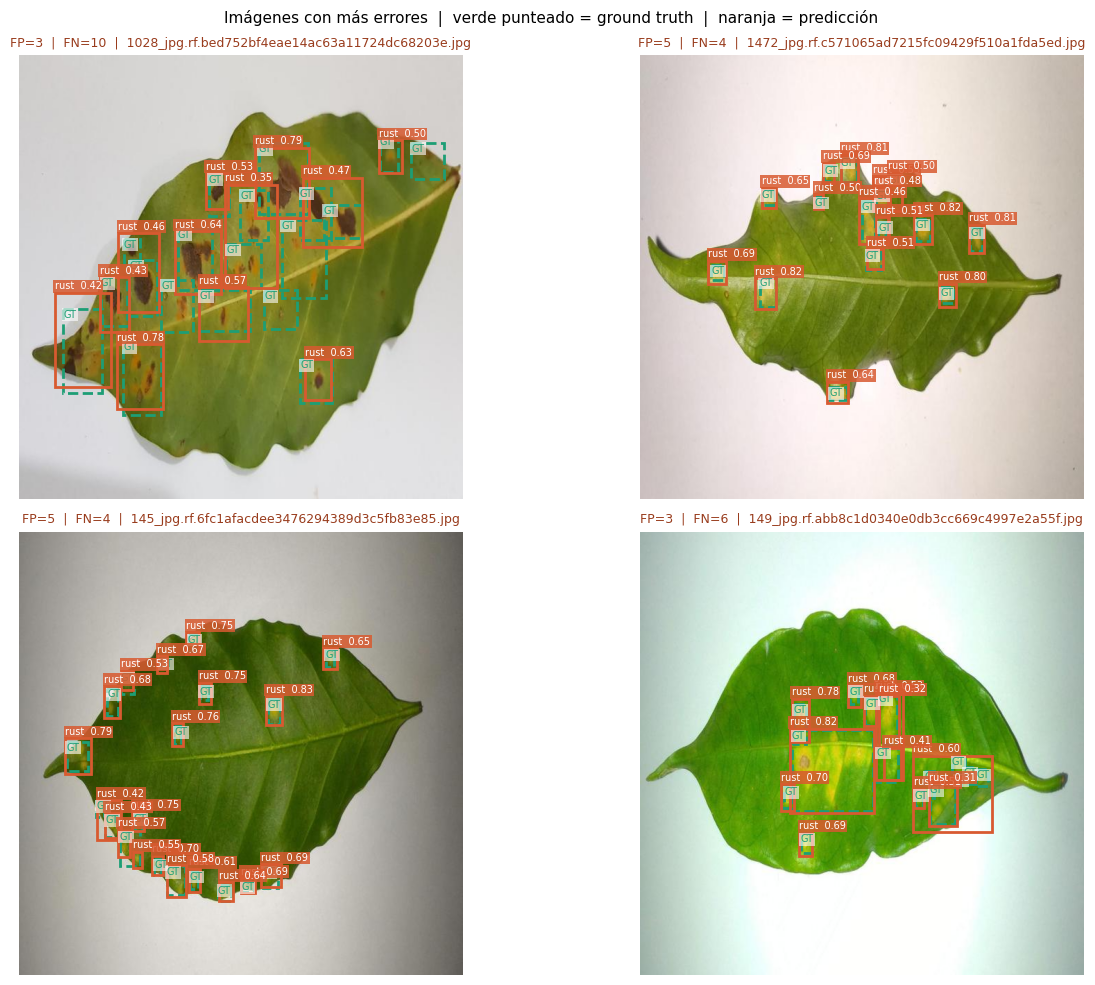

In [ ]:
peores = errores_por_imagen[:4]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "Imágenes con más errores  |  verde punteado = ground truth  |  naranja = predicción",
    fontsize=11
)

for ax, (total, fp, fn, img_path) in zip(axes.flat, peores):
    img = Image.open(img_path).convert("RGB")
    w, h = img.size
    ax.imshow(img)

    lbl_path = BASE_DIR / "valid" / "labels" / (img_path.stem + ".txt")
    if lbl_path.exists():
        for linea in lbl_path.read_text().strip().splitlines():
            if not linea:
                continue
            cid, xc, yc, bw, bh = map(float, linea.split())
            x1 = (xc - bw / 2) * w
            y1 = (yc - bh / 2) * h
            rect = patches.Rectangle(
                (x1, y1), bw * w, bh * h,
                linewidth=2, edgecolor="#1D9E75",
                facecolor="none", linestyle="--"
            )
            ax.add_patch(rect)
            ax.text(
                x1, y1 + 13, "GT",
                color="#1D9E75", fontsize=7,
                bbox=dict(fc="white", alpha=0.6, ec="none", pad=1)
            )

    preds_raw = model_eval.predict(
        source=str(img_path),
        conf=UMBRAL_CONFIANZA,
        iou=UMBRAL_NMS,
        verbose=False
    )[0]

    for box in preds_raw.boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        cid    = int(box.cls[0])
        conf   = float(box.conf[0])
        nombre = NAMES[cid] if cid < len(NAMES) else f"cls_{cid}"

        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor="#D85A30", facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(
            x1, y1 - 5,
            f"{nombre}  {conf:.2f}",
            color="white", fontsize=7,
            bbox=dict(fc="#D85A30", alpha=0.85, ec="none", pad=1)
        )

    ax.set_title(
        f"FP={fp}  |  FN={fn}  |  {img_path.name}",
        fontsize=9, color="#993C1D"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

Las cuatro imágenes con más errores corresponden exclusivamente a rust, confirmando lo que se ha planteado a lo largo del notebook. Se observan dos causas principales:

- En la primera y tercer imagen, las lesiones están densamente agrupadas y el modelo genera múltiples cajas solapadas sobre el mismo conjunto de manchas mientras que omite las lesiones individuales pequeñas.

- En la cuarta imagen, una zona de clorosis amarillenta en el centro de la hoja genera falsos positivos, porque el modelo confunde la decoloración natural de la hojas con sintomas de roya (rust).

Las confianzas bajas en estos casos indican que el modelo detecta algo pero con baja certeza.

## Sección 7 — Exportar el modelo

In [ ]:
# Exportar a ONNX (compatible con C++, Java, TensorRT, OpenVINO, etc.)
model_eval.export(format="onnx", imgsz=IMG_SIZE, simplify=True)
print("Modelo exportado a formato ONNX")

# Descargar el modelo desde Google Colab
try:
    from google.colab import files
    files.download(str(MEJOR_MODELO))
    print(f"Descarga iniciada: {MEJOR_MODELO}")
except ImportError:
    print(f"Modelo disponible localmente en: {MEJOR_MODELO}")

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/runs/detect/coffee_leaf_v6/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 8, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 234ms
Prepared 4 packages in 1.61s
Installed 4 packages in 261ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime==1.26.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 2.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 4.5s, saved as '/content/runs

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descarga iniciada: /content/runs/detect/coffee_leaf_v6/weights/best.pt


## Conclusiones

- El sistema de detección de enfermedades en hojas de café desarrollado en este proyecto demuestra que la visión computacional puede aportar valor real y medible en un problema agrícola concreto. Los resultados obtenidos en las métricas validan la viabilidad del enfoque para uso en producción.

- El fine-tuning demostró ser  la estrategia correcta para una dataset de tamaño moderado porque permitió alcanzar convergencia en ~35 épocas sin overfitting, algo que entrenar desde cero difícilmente lograría. La aumentación de datos fue determinante para compensar el desbalance de las clases, especialmente la escasez de instancias de healthy.

- La clase rust concentra la mayor parte de los errores del sistema porque tiene una alta densidad de lesiones por imagen, varia visualmente entre estadios de infección y tiene similitud cromática con la clorosis natural de la hoja; y esto lo sustentan las métricas por la brecha existente entre mAP@0.5 (0.96) y mAP@0.5:0.95 (0.71).

- El sistema no se limita a mostrar detecciones, la salida del modelo genera información cuantitativa por clase que puede orientar decisiones fitosanitarias reales. Un agricultor o técnico agronómo puede capturar una imagen de la hoja, obtener en segundos el diagnostico y decidir si intervenir. Esto transforma un proceso que hoy depende de inspección manual experta en uno automatizado, escalable y accesible desde un dispositivo móvil.

- Para continuar mejorando el sistema se propone ampliar el dataset con imágenes en condiciones adversas de iluminación y diferentes estadios de la roya, y explorar modelos de segmentación de instancias que permitan estimar el porcentaje de área foliar afectada.